In [10]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('uci-secom.csv')

# 데이터 앞부분 확인하기
df.head()


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [5]:
# Kaggle 원본 데이터 구조상 특성(Features)과 타겟(Labels)을 명확히 확인하기 위한 코드입니다.
# 전체 데이터의 크기와 비어있는 값(결측치)의 총 개수를 확인해봅시다.

print("전체 데이터 크기 (행, 열):", df.shape)
print("데이터 내 전체 결측치(빈칸) 개수:", df.isnull().sum().sum())

전체 데이터 크기 (행, 열): (1567, 592)
데이터 내 전체 결측치(빈칸) 개수: 41951


In [9]:
# 1. 빈 칸(결측치)이 50% 이상인 센서(열)는 아예 지워버리기
threshold = len(df) * 0.5
df_cleaned = df.dropna(thresh=threshold, axis=1)

# 2. 남은 미세한 빈 칸들은 각 센서의 '평균값'으로 채우기
# 숫자 데이터만 있는 열을 골라 평균값으로 채웁니다 (Time 열 제외)
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].mean())

# 3. 전처리 후 결측치가 잘 사라졌는지 확인
print("전처리 후 남은 데이터 크기:", df_cleaned.shape)
print("전처리 후 남은 결측치 개수:", df_cleaned.isnull().sum().sum())

전처리 후 남은 데이터 크기: (1567, 564)
전처리 후 남은 결측치 개수: 0


/tmp/ipykernel_505/2650220768.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].mean())


In [8]:
# 데이터 표의 '맨 마지막 열'이 무엇인지 자동으로 찾아서 타겟으로 지정합니다.
# 마지막 열 데이터를 가져오는 안전한 방법입니다.
last_col_name = df.columns[-1]

target_counts = df[last_col_name].value_counts()
print(f"--- 마지막 열('{last_col_name}') 기준 정상 제품 vs 불량 제품 개수 ---")
print(target_counts)

# 불량률(%) 계산해보기 (보통 불량은 1 또는 다른 양수 값으로 표현됩니다)
# 여기서는 분포가 어떻게 되어있는지 확인하기 위해 비율을 출력합니다.
total_count = len(df)
for val, cnt in target_counts.items():
    percentage = (cnt / total_count) * 100
    print(f"값 [{val}]의 비율: {percentage:.2f}% ({cnt}개)")

--- 마지막 열('Pass/Fail') 기준 정상 제품 vs 불량 제품 개수 ---
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
값 [-1]의 비율: 93.36% (1463개)
값 [1]의 비율: 6.64% (104개)


In [11]:
# 1. 문제집(X) 만들기: 시간(Time)과 정답(Pass/Fail) 열은 분석에 방해되므로 제외합니다.
X = df_cleaned.drop(columns=['Time', 'Pass/Fail'])

# 2. 정답지(y) 만들기: Pass/Fail 열만 쏙 빼옵니다.
y = df_cleaned['Pass/Fail']

print("문제집(센서 데이터 X)의 크기:", X.shape)
print("정답지(불량 여부 y)의 크기:", y.shape)

문제집(센서 데이터 X)의 크기: (1567, 562)
정답지(불량 여부 y)의 크기: (1567,)


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. 562개 센서 중 불량 여부와 가장 상관관계가 높은 탑 10개 센서 고르기
selector = SelectKBest(score_func=f_classif, k=10)
X_important = selector.fit_transform(X, y)

# 2. 선택된 10개 센서의 이름(번호) 확인하기
selected_features = X.columns[selector.get_support()]

print("--- 선택된 불량 핵심 원인 센서 Top 10 ---")
print(list(selected_features))
print("\n최종 정제된 문제집 크기:", X_important.shape)

--- 선택된 불량 핵심 원인 센서 Top 10 ---
['21', '28', '59', '103', '348', '430', '431', '434', '435', '510']

최종 정제된 문제집 크기: (1567, 10)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  5  13  42  49  52  69  94 135 143 170 171 178 181 182 183 184 185 186
 217 220 221 222 223 224 225 226 227 228 231 232 233 234 244 245 246 247
 248 249 250 251 252 253 254 264 272 299 300 301 308 311 312 313 314 315
 316 347 352 353 354 355 356 357 358 361 362 363 364 374 375 376 377 378
 379 380 381 382 383 384 394 402 429 430 431 438 441 442 443 444 445 446
 461 477 480 481 482 483 484 485 486 487 488 491 492 493 494 504 505 506
 507 508 509 510 511 512 513 514] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. 데이터를 학습용(80%)과 시험용(20%)으로 쪼갭니다. (컴퓨터가 치팅하지 못하게 시험지를 숨겨두는 과정)
X_train, X_test, y_train, y_test = train_test_split(X_important, y, test_size=0.2, random_state=42, stratify=y)

# 2. 의사결정나무 모델 가져오기
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# 3. 모델에게 학습용 문제집과 정답지 주고 공부시키기 (학습)
model.fit(X_train, y_train)

# 4. 공부한 모델에게 시험지(X_test)를 주고 문제를 풀게 하기 (예측)
y_pred = model.predict(X_test)

# 5. 최종 성적표 출력하기
print("최종 모델 예측 정확도(Accuracy):", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n--- 상세 성적표 (Classification Report) ---")
print(classification_report(y_test, y_pred))

최종 모델 예측 정확도(Accuracy): 93.31 %

--- 상세 성적표 (Classification Report) ---
              precision    recall  f1-score   support

          -1       0.94      0.99      0.97       293
           1       0.50      0.10      0.16        21

    accuracy                           0.93       314
   macro avg       0.72      0.54      0.56       314
weighted avg       0.91      0.93      0.91       314



In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 1. SMOTE를 이용해 학습 데이터의 '불량 제품(1)' 강제로 뻥튀기하기 (50:50 비율 맞추기)
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("--- SMOTE 적용 전 vs 후 학습 데이터 정답 개수 ---")
print("적용 전:\n", y_train.value_counts())
print("적용 후:\n", y_train_over.value_counts())

# 2. 나무 한 그루 대신 '랜덤 포레스트(숲)' 모델 가져와서 학습시키기
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_over, y_train_over)

# 3. 새로운 모델로 시험지 예측해보기
y_rf_pred = rf_model.predict(X_test)

# 4. 최종 업그레이드 성적표 출력
print("\n" + "="*40)
print("업그레이드 모델 예측 정확도:", round(accuracy_score(y_test, y_rf_pred) * 100, 2), "%")
print("="*40)
print("\n--- 새로운 상세 성적표 (Random Forest + SMOTE) ---")
print(classification_report(y_test, y_rf_pred))

--- SMOTE 적용 전 vs 후 학습 데이터 정답 개수 ---
적용 전:
 Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64
적용 후:
 Pass/Fail
-1    1170
 1    1170
Name: count, dtype: int64

업그레이드 모델 예측 정확도: 83.12 %

--- 새로운 상세 성적표 (Random Forest + SMOTE) ---
              precision    recall  f1-score   support

          -1       0.95      0.86      0.91       293
           1       0.17      0.38      0.23        21

    accuracy                           0.83       314
   macro avg       0.56      0.62      0.57       314
weighted avg       0.90      0.83      0.86       314



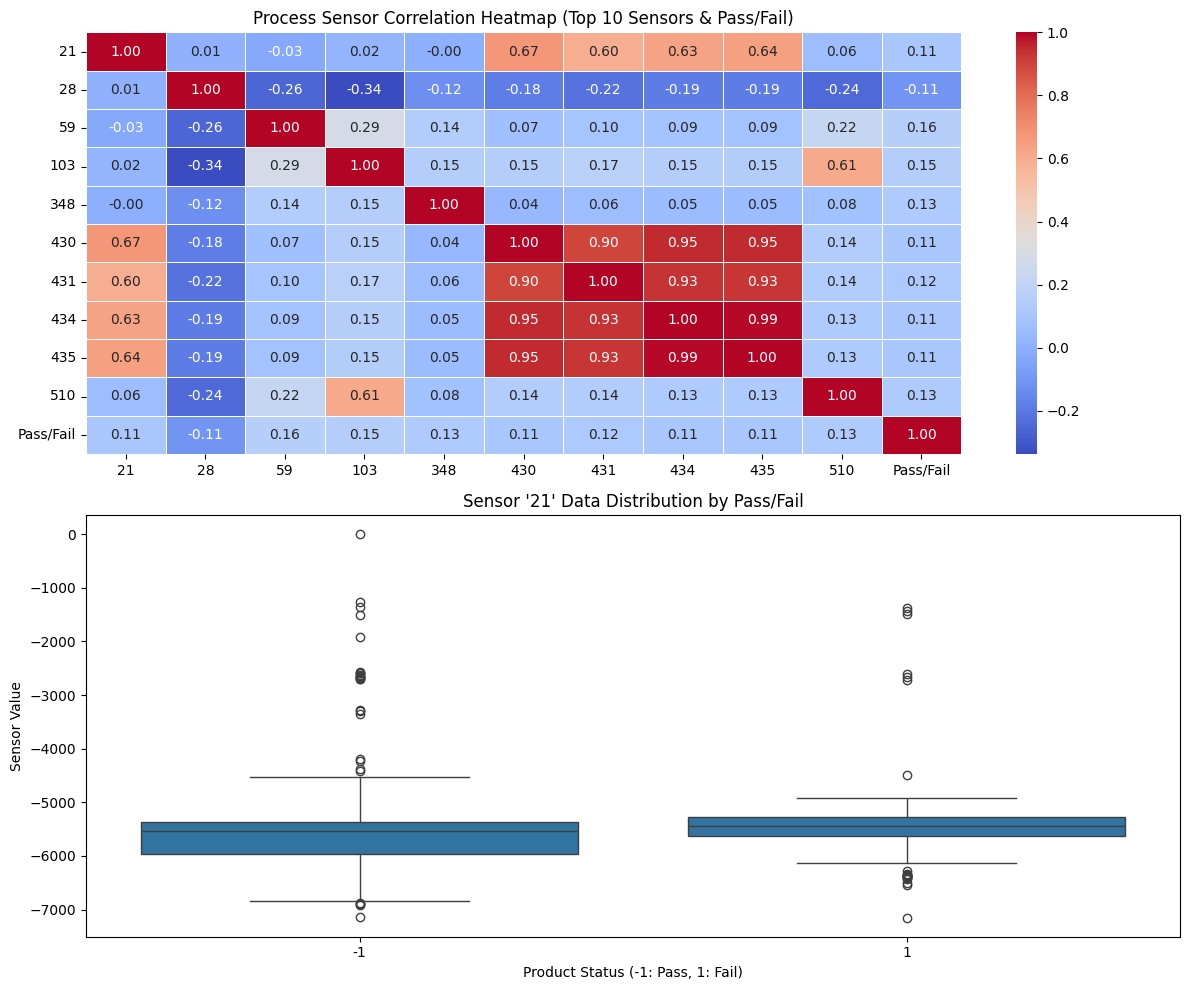

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 히트맵을 그리기 위해 탑 10 센서와 Pass/Fail 열을 하나로 합친 임시 데이터프레임 만들기
X_top10 = df_cleaned[selected_features]
combined_df = pd.concat([X_top10, y], axis=1)

# 그래프 크기 설정
plt.figure(figsize=(12, 10))

# [시각화 1] 상관관계 히트맵 그리기
plt.subplot(2, 1, 1)
sns.heatmap(combined_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Process Sensor Correlation Heatmap (Top 10 Sensors & Pass/Fail)")

# [시각화 2] 가장 점수가 높았던 탑 1위 센서와 불량률의 관계를 Box Plot으로 보기
# 예시로 탑 10 중 첫 번째 센서를 지정합니다.
top_sensor = selected_features[0]

plt.subplot(2, 1, 2)
sns.boxplot(x='Pass/Fail', y=top_sensor, data=combined_df)
plt.title(f"Sensor '{top_sensor}' Data Distribution by Pass/Fail")
plt.xlabel("Product Status (-1: Pass, 1: Fail)")
plt.ylabel("Sensor Value")

# 그래프 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')